# Electricity Demand EDA

Phase 1 only: dataset inspection and exploratory analysis. No forecasting model is trained here.

Bitcoin notebooks, results, metrics, and documentation are outside this notebook's scope and remain untouched.


## 1. Dataset Overview


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/")

REPO_ROOT = find_project_root(Path.cwd())
DATA_DIR = REPO_ROOT / "data" / "electricity"
TSF_PATH = DATA_DIR / "australian_electricity_demand_dataset.tsf"
files = pd.DataFrame([{
    "name": p.name, "type": p.suffix or "directory", "bytes": p.stat().st_size,
    "size_mib": round(p.stat().st_size / 2**20, 3)
} for p in sorted(DATA_DIR.rglob("*")) if p.is_file()])
display(files)
print("Exact TSF filename:", TSF_PATH.name)
print("Separate metadata files:", [p.name for p in DATA_DIR.iterdir() if p.suffix.lower() != ".tsf"])
print("Repository src.data_loader TSF support: unavailable")
print("Installed sktime/aeon TSF loader: unavailable; using the compatible parser below")


,name,type,bytes,size_mib
0,australian_electricity_demand_dataset.tsf,.tsf,13422464,12.801


Exact TSF filename: australian_electricity_demand_dataset.tsf
Separate metadata files: []
Repository src.data_loader TSF support: unavailable
Installed sktime/aeon TSF loader: unavailable; using the compatible parser below


## 2. Metadata


In [2]:
def load_tsf(path):
    metadata, attributes, rows = {}, [], []
    with Path(path).open(encoding="utf-8") as handle:
        for raw in handle:
            line = raw.strip()
            if not line or line.startswith("#"):
                continue
            if line.startswith("@attribute"):
                _, name, kind = line.split(maxsplit=2)
                attributes.append((name, kind))
            elif line.startswith("@") and not line.startswith("@data"):
                key, value = line[1:].split(maxsplit=1)
                metadata[key] = value
            elif not line.startswith("@"):
                parts = line.split(":", len(attributes))
                record = dict(zip((name for name, _ in attributes), parts[:-1]))
                record["series_value"] = np.fromstring(parts[-1], sep=",")
                rows.append(record)
    frame = pd.DataFrame(rows)
    return frame, metadata, attributes

series_df, metadata, attributes = load_tsf(TSF_PATH)
metadata_report = {
    **metadata,
    "forecast_horizon": "not specified in the TSF file",
    "number_of_series": len(series_df),
    "column_names": [name for name, _ in attributes] + ["series_value"],
}
display(pd.Series(metadata_report, name="value").to_frame())
display(pd.DataFrame(attributes, columns=["attribute", "declared_type"]))


,value
relation,Aus_Electricity_Demand
frequency,half_hourly
missing,false
equallength,false
forecast_horizon,not specified in the TSF file
number_of_series,5
column_names,"[series_name, state, start_timestamp, series_v..."


,attribute,declared_type
0,series_name,string
1,state,string
2,start_timestamp,date


## 3. Regional Series Inspection


In [3]:
regional = series_df.copy()
regional["start_timestamp"] = pd.to_datetime(regional["start_timestamp"], format="%Y-%m-%d %H-%M-%S")
regional["series_length"] = regional["series_value"].map(len)
regional["end_timestamp"] = regional.apply(
    lambda r: r["start_timestamp"] + pd.Timedelta(minutes=30*(r["series_length"]-1)), axis=1)
display(regional[["series_name", "state", "start_timestamp", "end_timestamp", "series_length"]])
print("All identifiers:", regional[["series_name", "state"]].to_dict("records"))


,series_name,state,start_timestamp,end_timestamp,series_length
0,T1,NSW,2002-01-01,2015-02-28 23:30:00,230736
1,T2,VIC,2002-01-01,2015-02-28 23:30:00,230736
2,T3,QUN,2002-01-01,2015-04-01 23:30:00,232272
3,T4,SA,2002-01-01,2015-03-01 23:30:00,230784
4,T5,TAS,2002-01-01,2015-02-28 23:30:00,230736


All identifiers: [{'series_name': 'T1', 'state': 'NSW'}, {'series_name': 'T2', 'state': 'VIC'}, {'series_name': 'T3', 'state': 'QUN'}, {'series_name': 'T4', 'state': 'SA'}, {'series_name': 'T5', 'state': 'TAS'}]


## 4. South Australia Series Selection


In [4]:
sa_match = regional[regional["state"].str.strip().str.casefold().isin(["sa", "south australia"])]
assert len(sa_match) == 1, "South Australia is not uniquely identifiable from state metadata."
sa_row = sa_match.iloc[0]
print("Selected from metadata (not row order):", {"series_name": sa_row["series_name"], "state": sa_row["state"]})
sa_index = pd.date_range(sa_row["start_timestamp"], periods=sa_row["series_length"], freq="30min")
sa = pd.Series(sa_row["series_value"], index=sa_index, name="Demand")


Selected from metadata (not row order): {'series_name': 'T4', 'state': 'SA'}


## 5. Data Quality Audit


In [5]:
expected = pd.date_range(sa.index.min(), sa.index.max(), freq="30min")
quality = pd.Series({
    "inferred_frequency": pd.infer_freq(sa.index),
    "chronologically_ordered": sa.index.is_monotonic_increasing,
    "duplicated_timestamps": int(sa.index.duplicated().sum()),
    "missing_timestamps": int(len(expected.difference(sa.index))),
    "missing_values": int(sa.isna().sum()),
    "zero_values": int(sa.eq(0).sum()),
    "negative_values": int(sa.lt(0).sum()),
    "48_observations_equal_one_day": sa.index[48] - sa.index[0] == pd.Timedelta(days=1),
    "336_observations_equal_one_week": sa.index[336] - sa.index[0] == pd.Timedelta(days=7),
})
display(quality.to_frame("value"))
summary = sa.describe().rename({"count":"observations", "25%":"q25", "50%":"median", "75%":"q75"})
summary.loc["start"] = str(sa.index.min())
summary.loc["end"] = str(sa.index.max())
summary.loc["days"] = len(sa)/48
summary.loc["approx_years"] = len(sa)/(48*365.2425)
display(summary.to_frame("value"))


,value
inferred_frequency,30min
chronologically_ordered,True
duplicated_timestamps,0
missing_timestamps,0
missing_values,0
zero_values,0
negative_values,0
48_observations_equal_one_day,True
336_observations_equal_one_week,True


,value
observations,230784.0
mean,1290.592171
std,301.121979
min,488.83538
q25,1063.493907
median,1271.576137
q75,1459.608088
max,3182.476646
start,2002-01-01 00:00:00
end,2015-03-01 23:30:00


## 6. Full Time-Series Plot


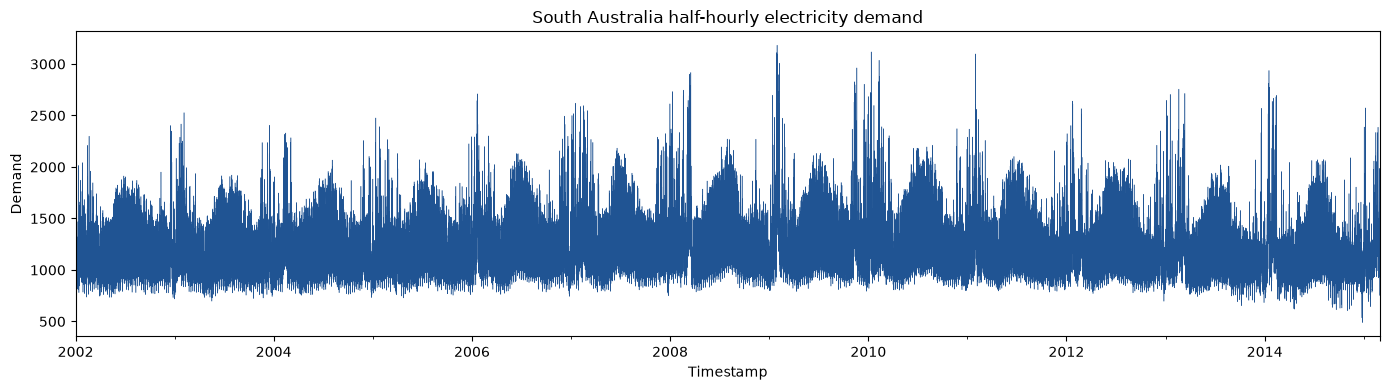

In [6]:
ax = sa.plot(figsize=(14,4), lw=.35, color="#205493", title="South Australia half-hourly electricity demand")
ax.set(xlabel="Timestamp", ylabel="Demand"); plt.tight_layout(); plt.show()


## 7. Recent 30-Day Plot


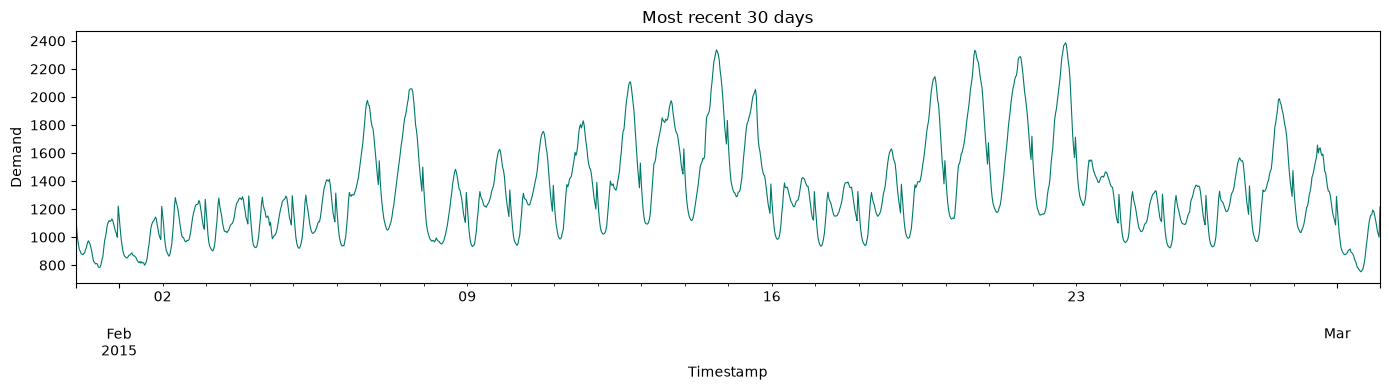

In [7]:
recent = sa.iloc[-48*30:]
ax = recent.plot(figsize=(14,4), lw=.8, color="#00796b", title="Most recent 30 days")
ax.set(xlabel="Timestamp", ylabel="Demand"); plt.tight_layout(); plt.show()


## 8. One-Week Demand Pattern


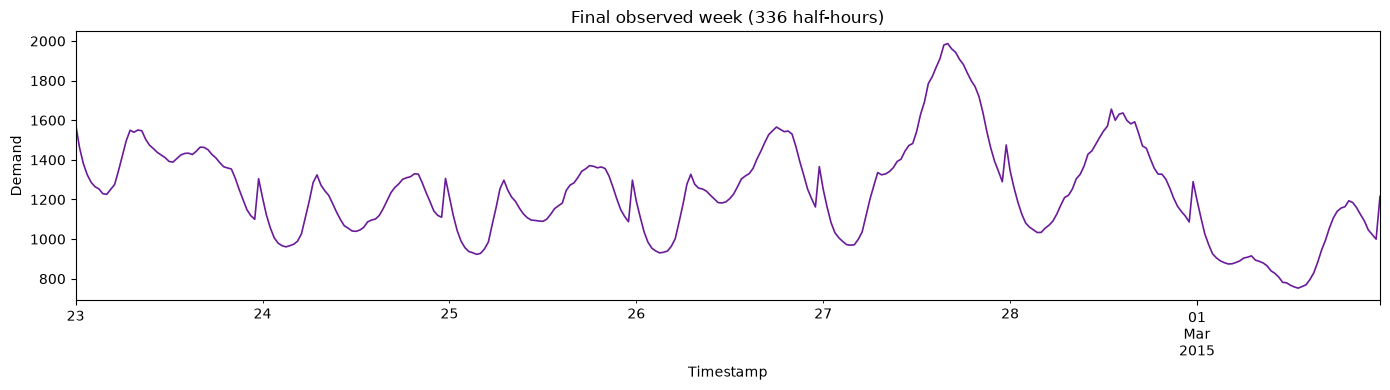

In [8]:
week = sa.iloc[-336:]
ax = week.plot(figsize=(14,4), lw=1.2, color="#6a1b9a", title="Final observed week (336 half-hours)")
ax.set(xlabel="Timestamp", ylabel="Demand"); plt.tight_layout(); plt.show()


## 9. Distribution


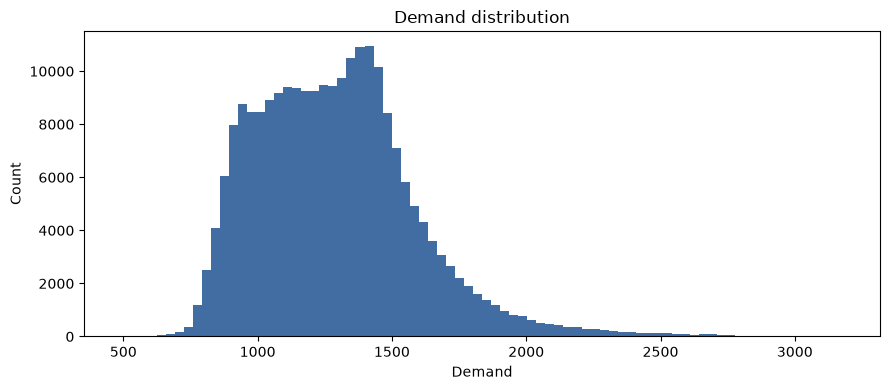

,Demand
0.01,799.771222
0.05,877.612535
0.25,1063.493907
0.50,1271.576137
0.75,1459.608088
0.95,1811.789534
0.99,2232.510865


In [9]:
fig, ax = plt.subplots(figsize=(9,4)); ax.hist(sa, bins=80, color="#205493", alpha=.85)
ax.set(title="Demand distribution", xlabel="Demand", ylabel="Count"); plt.tight_layout(); plt.show()
display(sa.quantile([.01,.05,.25,.5,.75,.95,.99]).to_frame("Demand"))


## 10. Daily Seasonality


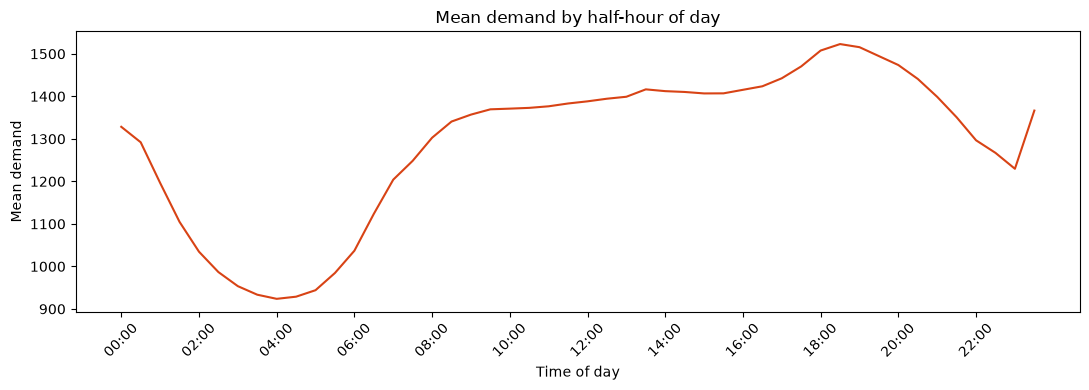

Daily-profile low: 04:00 923.74
Daily-profile peak: 18:30 1522.92


In [10]:
tod = sa.groupby(sa.index.strftime("%H:%M")).mean()
ax = tod.plot(figsize=(11,4), color="#d84315", title="Mean demand by half-hour of day")
ax.set(xlabel="Time of day", ylabel="Mean demand"); ax.set_xticks(range(0,48,4)); ax.set_xticklabels(tod.index[::4], rotation=45)
plt.tight_layout(); plt.show()
print("Daily-profile low:", tod.idxmin(), round(tod.min(),2)); print("Daily-profile peak:", tod.idxmax(), round(tod.max(),2))


## 11. Weekly Seasonality


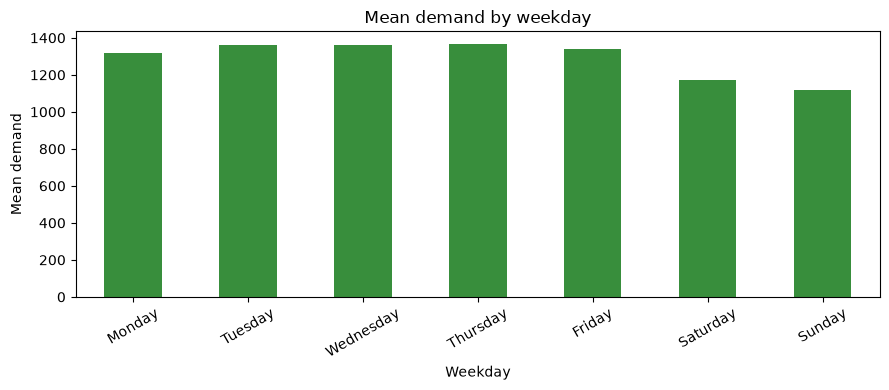

,mean_demand
Monday,1320.598837
Tuesday,1359.538690
Wednesday,1361.122033
Thursday,1366.807920
Friday,1337.770974
Saturday,1171.989178
Sunday,1116.361246


In [11]:
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow = sa.groupby(sa.index.day_name()).mean().reindex(order)
ax = dow.plot(kind="bar", figsize=(9,4), color="#388e3c", title="Mean demand by weekday")
ax.set(xlabel="Weekday", ylabel="Mean demand"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()
display(dow.to_frame("mean_demand"))


## 12. Autocorrelation and Lag Analysis


,lag_half_hours,autocorrelation,interpretation
0,1,0.984394,30 minutes
1,2,0.949438,1 hour
2,48,0.807537,1 day
3,96,0.612894,2 days
4,336,0.699652,1 week
5,672,0.663855,2 weeks


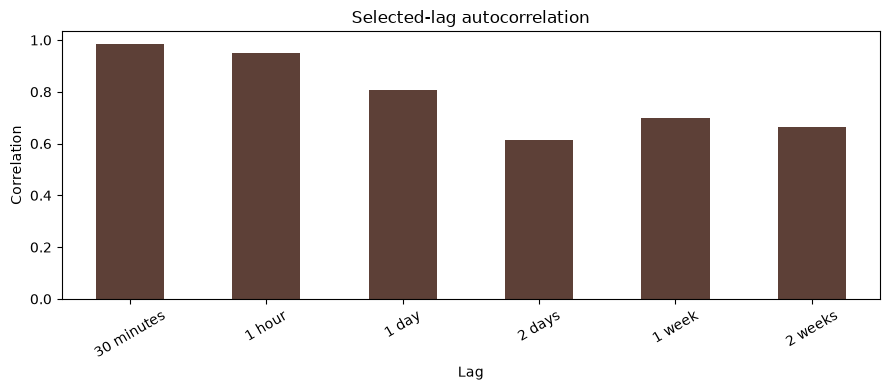

In [12]:
lags = [1,2,48,96,336,672]
lag_table = pd.DataFrame({"lag_half_hours": lags, "autocorrelation": [sa.autocorr(k) for k in lags]})
lag_table["interpretation"] = ["30 minutes","1 hour","1 day","2 days","1 week","2 weeks"]
display(lag_table)
ax = lag_table.plot.bar(x="interpretation", y="autocorrelation", legend=False, figsize=(9,4), color="#5d4037")
ax.set(title="Selected-lag autocorrelation", xlabel="Lag", ylabel="Correlation"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()


## 13. Peak and Low Demand Behaviour


In [13]:
q01, q99 = sa.quantile([.01,.99])
extremes = pd.Series({"1st percentile":q01,"99th percentile":q99,"low observations":int((sa<=q01).sum()),"peak observations":int((sa>=q99).sum())})
display(extremes.to_frame("value"))
top = sa.nlargest(10).rename("Demand").to_frame(); top["weekday"] = top.index.day_name(); top["time"] = top.index.strftime("%H:%M")
display(top)


,value
1st percentile,799.771222
99th percentile,2232.510865
low observations,2308.000000
peak observations,2308.000000


,Demand,weekday,time
2009-01-29 16:00:00,3182.476646,Thursday,16:00
2009-01-29 13:30:00,3171.980654,Thursday,13:30
2009-01-29 15:30:00,3168.398232,Thursday,15:30
2009-01-29 16:30:00,3168.079536,Thursday,16:30
2009-01-29 13:00:00,3162.350392,Thursday,13:00
2009-01-29 17:00:00,3153.684330,Thursday,17:00
2009-01-29 12:30:00,3142.421778,Thursday,12:30
2009-01-29 15:00:00,3120.763486,Thursday,15:00
2010-01-11 12:30:00,3117.644614,Monday,12:30
2010-01-11 13:30:00,3111.634312,Monday,13:30


## 14. Candidate Train-Test Design


In [14]:
split_n = int(len(sa)*.8); split_n -= split_n % 48
train, test = sa.iloc[:split_n], sa.iloc[split_n:]
split = pd.DataFrame({
    "period":["Train (80%)","Test (20%)"], "observations":[len(train),len(test)],
    "start":[train.index.min(),test.index.min()], "end":[train.index.max(),test.index.max()],
    "days":[len(train)/48,len(test)/48]
})
display(split)
print("Boundary is midnight and day-aligned:", test.index.min().time() == pd.Timestamp("00:00").time())
print("Design: chronological only; no random split. All fitted preprocessing must use train only.")


,period,observations,start,end,days
0,Train (80%),184608,2002-01-01,2012-07-12 23:30:00,3846.0
1,Test (20%),46176,2012-07-13,2015-03-01 23:30:00,962.0


Boundary is midnight and day-aligned: True
Design: chronological only; no random split. All fitted preprocessing must use train only.


## 15. Candidate Forecast Horizons


In [15]:
horizons = pd.DataFrame({
    "purpose":["Protocol A: rolling one-step","Short diagnostic","Protocol B: day-ahead","Seasonal stress test"],
    "steps":[1,7,48,336], "elapsed_time":["30 minutes","3.5 hours","24 hours","7 days"],
    "status":["primary","smoke test","primary separate evaluation","candidate only"]
})
display(horizons)
print("Original Monash benchmark horizon: not declared in this TSF file; verify separately in Phase 2 documentation.")
print("Rolling one-step and 48-step day-ahead results must remain separately labelled.")


,purpose,steps,elapsed_time,status
0,Protocol A: rolling one-step,1,30 minutes,primary
1,Short diagnostic,7,3.5 hours,smoke test
2,Protocol B: day-ahead,48,24 hours,primary separate evaluation
3,Seasonal stress test,336,7 days,candidate only


Original Monash benchmark horizon: not declared in this TSF file; verify separately in Phase 2 documentation.
Rolling one-step and 48-step day-ahead results must remain separately labelled.


## 16. Key Findings


In [16]:
findings = [
    f"South Australia is explicitly identified by metadata as {sa_row['series_name']} / {sa_row['state']}.",
    f"The series has {len(sa):,} complete half-hourly observations from {sa.index.min()} to {sa.index.max()}.",
    "There are no duplicated or missing timestamps, missing values, zeros, or negative values.",
    f"Strong persistence and seasonality are visible: lag-1={sa.autocorr(1):.3f}, lag-48={sa.autocorr(48):.3f}, lag-336={sa.autocorr(336):.3f}.",
    f"The average intraday trough occurs at {tod.idxmin()} and peak at {tod.idxmax()}.",
    f"Average demand is lowest on {dow.idxmin()} and highest on {dow.idxmax()}.",
    "A day-aligned chronological 80/20 split is suitable for initial protocol design.",
    "Primary horizons should be one half-hour and a separately evaluated 48-step day-ahead horizon."
]
for item in findings: print("-", item)


- South Australia is explicitly identified by metadata as T4 / SA.
- The series has 230,784 complete half-hourly observations from 2002-01-01 00:00:00 to 2015-03-01 23:30:00.
- There are no duplicated or missing timestamps, missing values, zeros, or negative values.
- Strong persistence and seasonality are visible: lag-1=0.984, lag-48=0.808, lag-336=0.700.
- The average intraday trough occurs at 04:00 and peak at 18:30.
- Average demand is lowest on Sunday and highest on Thursday.
- A day-aligned chronological 80/20 split is suitable for initial protocol design.
- Primary horizons should be one half-hour and a separately evaluated 48-step day-ahead horizon.
